# Tianshou: Multi-Agent Collaboration in a Grid World
This notebook contains some example implementations of Grid World reinforcement learning training using the environment defined in the API notebook. The notebook demonstrates the following, in order:  
1. How the grid world looks with a random policy and a single agent
2. Training with a single agent in the grid world, using the neural network defined in the API notebook
3. Training with multiple independent agents in the grid world using the same neural network, along with difficulties that arise as a result
4. Training with multiple agents controlled by a central policy using the same neural network

## Imports
First, to "import" the classes defined in the API notebook, run the other notebook with a magic command.

In [1]:
%run tianshou.API.ipynb

  Using cached gym-0.21.0.tar.gz (1.5 MB)
  Preparing metadata (setup.py) ... done
Requested gym==0.21.0 from https://files.pythonhosted.org/packages/4b/48/920cea66177b865663fde5a9390a59de0ef3b642ad98106ac1d8717d7005/gym-0.21.0.tar.gz has invalid metadata: Expected end or semicolon (after version specifier)
    opencv-python>=3.
                 ~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement gym==0.21.0 (from versions: 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.1.0, 0.1.1, 0.1.2, 0.1.3, 0.1.4, 0.1.5, 0.1.6, 0.1.7, 0.2.0, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.2.6, 0.2.7, 0.2.8, 0.2.9, 0.2.10, 0.2.11, 0.2.12, 0.3.0, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.8, 0.4.9, 0.4.10, 0.5.0, 0.5.1, 0.5.2, 0.5.3, 0.5.4, 0.5.5, 0.5.6, 0.5.7, 0.6.0, 0.7.0, 0.7.1, 0.7.2, 0.7.3, 0.7.4, 0.8.0.dev0, 0.8.0, 0.8.1, 0.8.2, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.9.7, 0.10.0, 0.10.1, 0.10.2, 0.10.3, 0.10.4, 0.10.5

Then, import utility functions that implement the training loop from tianshou.utils.py, along with the PettingZooEnv wrapper.

In [2]:
import tianshou_utils
from tianshou_utils import get_parser, get_agents, train_agent, watch

In [3]:
from tianshou.env.pettingzoo_env import PettingZooEnv

## Grid World Example
This is an example of what running the grid world would look like. In the below cell, the agent is taking purely random actions.

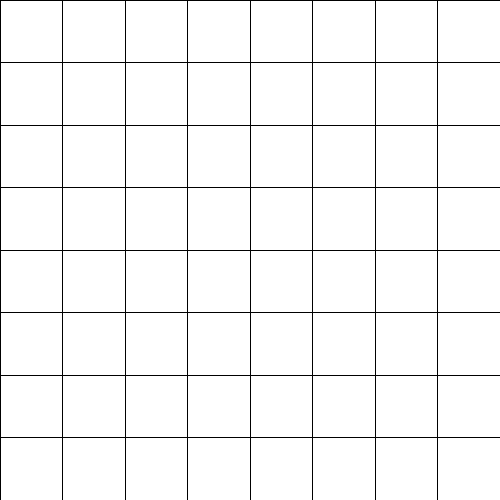

In [4]:
# MultiAgentGridWorld example with a random policy
import time
env = MultiAgentGridWorld(num_agents = 1)
obs, info = env.reset()
for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()
    action = env.action_space(agent).sample()
    obs, rew, term, trunc, info = env.step(action)
    frame = env.render()
    time.sleep(0.1)
env.close()

## Training a Single Agent Baseline
In order to demonstrate how the coin collecting problem works, we first train with a single agent. This agent must explore the grid and collect coins, while having a limited range of view as defined by the view_radius parameter. Training utilizes the DQN policy, which is ideal for small discrete action spaces.

Feel free to change the parameters in the environment definition to see what happens.

In [28]:
def generate_single_agent_env(render_mode = None):
    """Creates a grid world with 1 agent. Function format is required to work with vectorized environments."""
    return PettingZooEnv(MultiAgentGridWorld(size=8, num_agents=1, num_coins=2, view_radius=2, render_mode = render_mode))

# Setting training parameters
parser = get_parser()
args = parser.parse_known_args()[0]
args.num_agents = 1
print(args)

Namespace(batch_size=64, buffer_size=100000, device='cpu', epoch=80, eps_test=0.05, eps_train=0.95, gamma=0.95, hidden_sizes=[128, 128, 128, 128], logdir='log', lr=0.0001, n_step=3, num_agents=1, opponent_path='', opponent_sync_interval=1, render=0.1, resume_path='', seed=1626, step_per_collect=10, step_per_epoch=1000, target_update_freq=320, test_num=10, training_num=10, update_per_step=0.1, watch=False)


In [6]:
# Training loop
result, single_agent = train_agent(generate_single_agent_env, args, QNet)

Epoch #1: 1001it [00:01, 503.16it/s, agent0/loss=4.235, env_step=1000, len=18, n/ep=0, n/st=10, rew=34.83]              


[Epoch] env_step=1000  avg_train_reward=5.222
Epoch #1: test_reward: -38.750000 ± 0.000000, best_reward: -38.550000 ± 0.000000 in #0


Epoch #2: 1001it [00:02, 480.31it/s, agent0/loss=6.095, env_step=2000, len=128, n/ep=0, n/st=10, rew=13.25]             


[Epoch] env_step=2000  avg_train_reward=24.505
Epoch #2: test_reward: 1.107000 ± 0.000000, best_reward: 1.107000 ± 0.000000 in #2


Epoch #3: 1001it [00:02, 495.15it/s, agent0/loss=7.101, env_step=3000, len=103, n/ep=0, n/st=10, rew=29.28]             


...

[Epoch] env_step=78000  avg_train_reward=35.799
Epoch #78: test_reward: 35.940000 ± 0.000000, best_reward: 37.891000 ± 0.000000 in #8


Epoch #79: 1001it [00:02, 434.24it/s, agent0/loss=5.859, env_step=79000, len=10, n/ep=1, n/st=10, rew=34.91]            


[Epoch] env_step=79000  avg_train_reward=35.605
Epoch #79: test_reward: 35.797000 ± 0.000000, best_reward: 37.891000 ± 0.000000 in #8


Epoch #80: 1001it [00:02, 488.54it/s, agent0/loss=6.024, env_step=80000, len=20, n/ep=0, n/st=10, rew=37.01]            


[Epoch] env_step=80000  avg_train_reward=35.612
Epoch #80: test_reward: 35.259000 ± 0.000000, best_reward: 37.891000 ± 0.000000 in #8


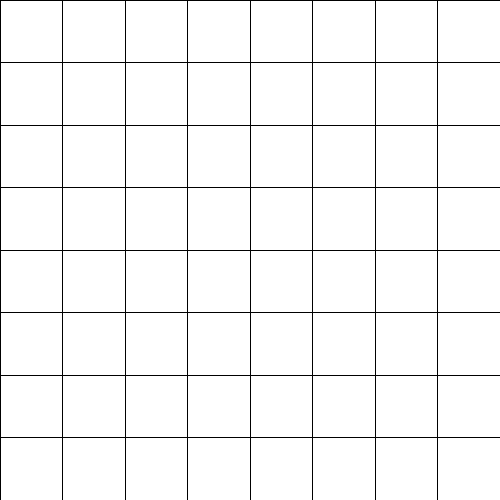

Final reward: 35.379999999999995, length: 13.0


In [17]:
# Visualized result - this should be replayable
args.num_agents = 1
watch(generate_single_agent_env, args, QNet, single_agent)

You may notice that the agent may intentionally meander, and the reward is larger when episodes are longer. This is because it receives a small reward for entering new visited spaces, in order to encourage exploration of a wider range of cells. For our intents and purposes, "collecting all coins" is the only metric we care about.

## Training Multiple Independent Agents
Problems arise when we switch from a single agent to 2 agents. Even when both agents have completely separate rewards and the same algorithm as the single agent training loop, adding more agents introduces **non-stationarity**. In DQN, agents are treated as part of the environment, and because their policies are constantly evolving, the "optimal" strategy becomes more difficult to learn, even when absolutely nothing has changed.

In [8]:
# Training a multi-agent grid world
def generate_multi_agent_env(render_mode = None):
    return PettingZooEnv(MultiAgentGridWorld(size=8, num_agents=2, num_coins=2, view_radius=2, render_mode = render_mode))
args.num_agents = 2
print(args)

Namespace(action_shape=4, batch_size=64, buffer_size=100000, device='cpu', epoch=80, eps_test=0.05, eps_train=0.95, gamma=0.95, hidden_sizes=[128, 128, 128, 128], logdir='log', lr=0.0001, n_step=3, num_agents=2, opponent_path='', opponent_sync_interval=1, render=0.1, resume_path='', seed=1626, step_per_collect=10, step_per_epoch=1000, target_update_freq=320, test_num=10, training_num=10, update_per_step=0.1, watch=False)


In [9]:
result, multi_agent = train_agent(generate_multi_agent_env, args, QNet)

Epoch #1: 1001it [00:03, 330.94it/s, agent0/loss=4.453, agent1/loss=4.027, env_step=1000, len=128, n/ep=0, n/st=10, rew=-3.53]


[Epoch] env_step=1000  avg_train_reward=-3.530
Epoch #1: test_reward: -21.830000 ± 0.000000, best_reward: -21.830000 ± 0.000000 in #1


Epoch #2: 1001it [00:02, 421.78it/s, agent0/loss=6.244, agent1/loss=5.407, env_step=2000, len=128, n/ep=0, n/st=10, rew=13.17]


[Epoch] env_step=2000  avg_train_reward=13.170
Epoch #2: test_reward: -12.320000 ± 0.000000, best_reward: -12.320000 ± 0.000000 in #2


Epoch #3: 1001it [00:02, 424.78it/s, agent0/loss=5.213, agent1/loss=6.656, env_step=3000, len=87, n/ep=0, n/st=10, rew=30.04]


...

[Epoch] env_step=78000  avg_train_reward=38.038
Epoch #78: test_reward: 35.869000 ± 0.000000, best_reward: 37.441000 ± 0.000000 in #66


Epoch #79: 1001it [00:03, 292.80it/s, agent0/loss=9.918, agent1/loss=9.524, env_step=79000, len=50, n/ep=0, n/st=10, rew=36.21]


[Epoch] env_step=79000  avg_train_reward=38.075
Epoch #79: test_reward: 35.012000 ± 0.000000, best_reward: 37.441000 ± 0.000000 in #66


Epoch #80: 1001it [00:03, 290.31it/s, agent0/loss=10.352, agent1/loss=9.550, env_step=80000, len=38, n/ep=0, n/st=10, rew=37.33]


[Epoch] env_step=80000  avg_train_reward=38.504
Epoch #80: test_reward: 19.531000 ± 0.000000, best_reward: 37.441000 ± 0.000000 in #66


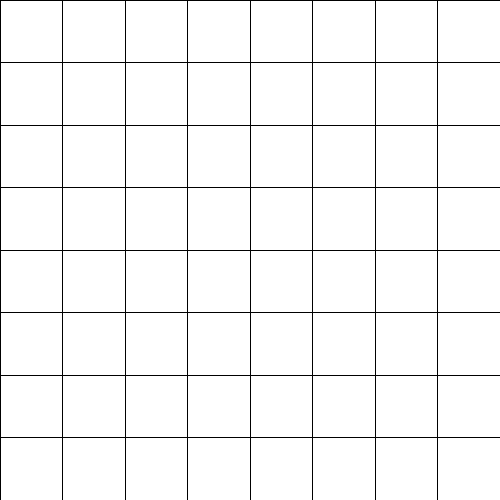

Final reward: 35.589999999999876, length: 92.0


In [18]:
args.num_agents = 2
watch(generate_multi_agent_env, args, QNet, multi_agent)

So how do you fix this? There are two main solutions. The first is to switch to a different policy that is more suited to non-stationary, multi-agent problems, such as PPO or an actor-critic method. The other method is to create a centralized policy that controls both agents. This is the method that the rest of this notebook will explore.

## Centralized Policy
The next training loop will train a single policy that directs both agents at the same time. Essentially, rather than 2 independent agents with 4 moves each, this is 1 agent with 16 possible moves (every combination of moves from 2 different agents). Additionally, both agents will "share" their observations with each other. This is done by stacking their observations on top of each other, before passing the combined observations to the neural network. Although it is not without faults, this method has a higher chance of successfully collecting all coins than an unchanged independent multi-agent training loop.

In [29]:
from tianshou_utils import get_centralized_policy, train_centralized_policy, watch_centralized

In [33]:
# Training a centralized policy in a grid world
def generate_centralized_env(render_mode = None):
    return CentralizedEnv(size=8, num_agents=args.num_agents, num_coins=2, view_radius=2, render_mode=render_mode)
args.num_agents = 2

In [34]:
args.epoch = 100
result, central_agent = train_centralized_policy(generate_centralized_env, args, QNet)

Epoch #1: 1001it [00:00, 1137.45it/s, env_step=1000, len=128, loss=15.778, n/ep=0, n/st=10, rew=-88.85]                 


[Epoch] env_step=1000  avg_train_reward=-88.850
Epoch #1: test_reward: -86.290000 ± 22.068369, best_reward: -86.290000 ± 22.068369 in #1


Epoch #2: 1001it [00:01, 916.16it/s, env_step=2000, len=128, loss=34.466, n/ep=0, n/st=10, rew=-3.85]                   


[Epoch] env_step=2000  avg_train_reward=103.722
Epoch #2: test_reward: -132.160000 ± 37.590605, best_reward: -86.290000 ± 22.068369 in #1


Epoch #3: 1001it [00:01, 915.85it/s, env_step=3000, len=128, loss=50.295, n/ep=0, n/st=10, rew=-11.38]                  


...

[Epoch] env_step=98000  avg_train_reward=169.145
Epoch #98: test_reward: 132.274000 ± 77.967881, best_reward: 172.275000 ± 3.560593 in #91


Epoch #99: 1001it [00:01, 590.49it/s, env_step=99000, len=26, loss=164.690, n/ep=0, n/st=10, rew=168.34]                


[Epoch] env_step=99000  avg_train_reward=168.512
Epoch #99: test_reward: 154.841000 ± 45.524286, best_reward: 172.275000 ± 3.560593 in #91


Epoch #100: 1001it [00:01, 574.35it/s, env_step=100000, len=34, loss=156.128, n/ep=1, n/st=10, rew=170.36]              


[Epoch] env_step=100000  avg_train_reward=169.661
Epoch #100: test_reward: 115.595000 ± 82.957772, best_reward: 172.275000 ± 3.560593 in #91


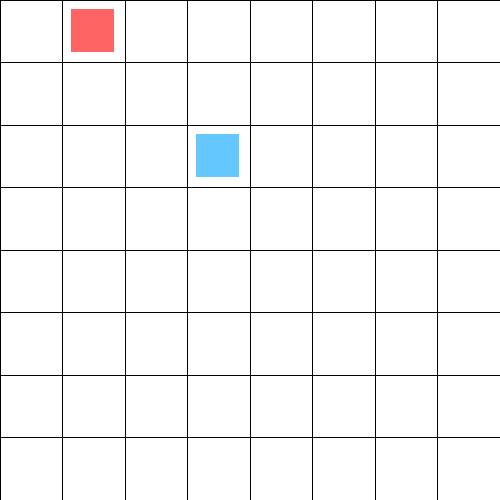

Final reward: 172.33000000000004, length: 27.0


In [37]:
args.num_agents = 2
watch_centralized(generate_centralized_env, args, QNet, central_agent)

As you can see, there are still issues. Most notably, in the current implementation of the centralized policy, agents' observations are simply stacked on top of each other, with no clear indication as to which set of observations correspond to which agent. This creates a phenomenon where the central policy is most likely to choose the same move for both agents together, rather than making independent choices for each agent, which is what you can see in the visualization above.

Unfortunately, I ran out of time to completely fix this issue, but the next steps from here would be to modify the centralized environment defined in the API notebook to add some observation that more strongly identifies each agent's set of observations.

Thank you for reading until the end!